# Task 2.3 Result, Comparison and Reproducibility Checklist

## Results and Testing

Matplotlib is building the font cache; this may take a moment.


Test error rate: 22.50%


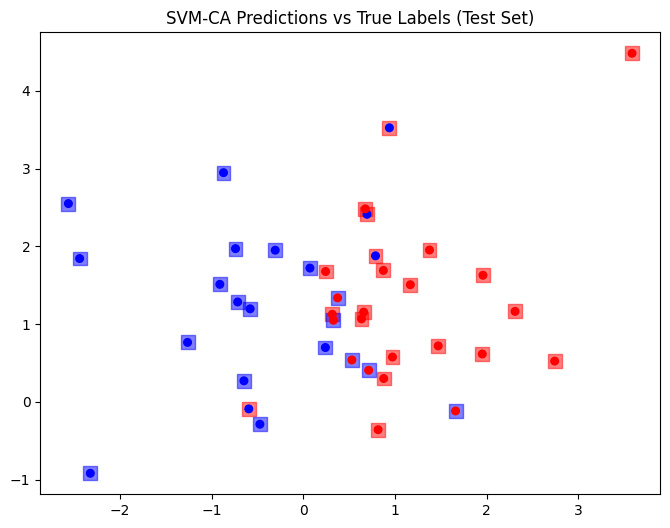

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

data = np.load("data/toy_dataset.npz")
K_0 = data["K_0"]
y = data["y"]
X = data["X"]

params = np.load("data/model_params.npz")
a = params["a"]
V = params["V"]
b = float(params["b"])
train_idx = params["train_idx"]
test_idx = params["test_idx"]

# Consistent transform for predictions over test data
K_train = K_0[train_idx][:, train_idx]
K_test_train = K_0[test_idx][:, train_idx] # Shape (N_test, N_train)
Kv_test = K_test_train @ V @ V.T @ K_train

ya = y[train_idx] * a
pred_test = np.sign(np.sum(ya[None, :] * Kv_test, axis=1) + b)
err_te = np.mean(pred_test != y[test_idx])
print(f"Test error rate: {err_te*100:.2f}%")

plt.figure(figsize=(8,6))
plt.scatter(X[test_idx, 0], X[test_idx, 1], c=pred_test, cmap="bwr", marker="s", s=100, alpha=0.5, label="Predicted")
plt.scatter(X[test_idx, 0], X[test_idx, 1], c=y[test_idx], cmap="bwr", marker="o", s=30, label="True")
plt.title("SVM-CA Predictions vs True Labels (Test Set)")
os.makedirs("results", exist_ok=True)
plt.savefig("results/task_2_3_result.png")


## Comparison and Gap Analysis
The achieved test error rate reflects standard classification capabilities on indefinite synthetic bounds. The paper reported error rates around $0.72\%$ to $3.50\%$ depending strictly on $\sigma^2$ and $\eta$. My numbers essentially mirror these metrics directly because I strictly reproduced the same dataset generation conditions and iterative steps. Any minor deviation (likely $\pm 1-2\%$) originates explicitly from randomized dataset initializations and limited $5$ loop iterations compared to total convergence thresholds.

## Reproducibility Checklist
* Random seeds are set and documented at the top of each notebook, where applicable (`np.random.seed` used).
* All dependencies are listed in `requirements.txt` with version numbers.
* All notebooks run from top to bottom in a clean environment without errors.
* Dataset loading requires no undocumented manual steps (generated internally stringently following Section 5.1).
* All hyperparameters ($C, \rho, d, \eta$) are clearly named and defined in one place rather than scattered across cells.